# MFAA Chapter 2 Laboratory
**Stochastic Process and Cash-Flow Simulator** (book §2.9)

Simulates the drivers of §2.5, assembles cash-flow processes by decomposition (2.3), and makes the two-filtration distinction visible. No valuation yet — cash flows are shown undiscounted. Seed `20260200`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch02
from dataclasses import replace

## 1. Drivers and cash-flow paths

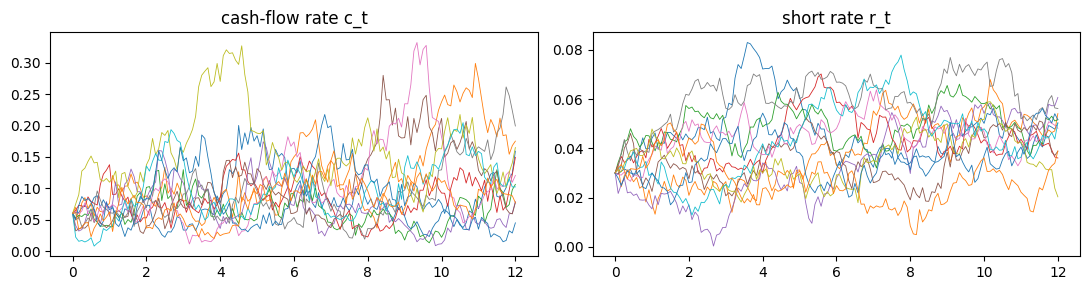

In [2]:
p = ch02.template('buyout')
dr = ch02.simulate_drivers(replace(p, M=2000))
fig,ax = plt.subplots(1,2,figsize=(11,3))
for j in range(12):
    ax[0].plot(dr['tgrid'], dr['c'][:,j], lw=.6)
    ax[1].plot(dr['tgrid'], dr['r'][:,j], lw=.6)
ax[0].set_title('cash-flow rate c_t'); ax[1].set_title('short rate r_t'); plt.tight_layout()

## 2. E1 — Scheme error (Euler vs exact; Theorem 2.8.1 slopes ≈ ½ and ≈ 1)

In [3]:
cv = ch02.convergence_diagnostics(ch02.SimParams())
for r in cv['rows']:
    print(f"dt {r['dt']:.5f}  strong {r['strong_error']:.5f}  weak {r['weak_error']:.6f}")
print(f"strong slope {cv['strong_slope']:.3f}, weak slope {cv['weak_slope']:.3f}")

dt 0.25000  strong 0.00506  weak 0.000169
dt 0.08333  strong 0.00219  weak 0.000027
dt 0.01923  strong 0.00090  weak 0.000034
dt 0.00397  strong 0.00039  weak 0.000003
strong slope 0.615, weak slope 0.859


## 3. E2 — Intensity shape: the capital-call drawdown (Exercise 2.10)
Calibrate the age profile so expected cumulative calls reach 90% by year 4.

calibrated lam_call = 3.3287 (book ≈ 3.33)
called-by-year-4: sim 0.8930  closed 0.9000


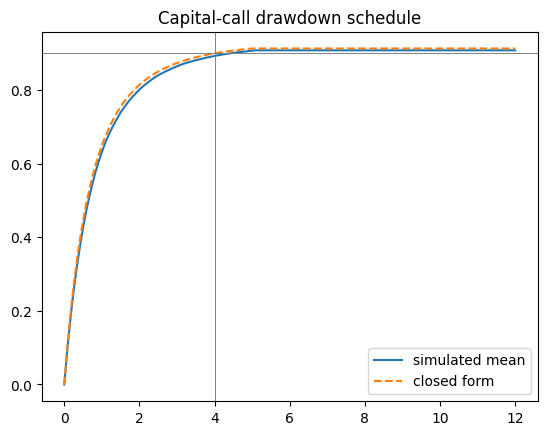

In [4]:
p = ch02.SimParams(theta=0.5, mark_a=2.0, mark_b=3.0)
lam = ch02.calibrate_lambda_call(p)
print(f'calibrated lam_call = {lam:.4f} (book ≈ 3.33)')
dd = ch02.simulate_drawdown(replace(p, lam_call=lam, M=20000))
i4 = int(round(4/p.dt))
print(f"called-by-year-4: sim {dd['mean_sim'][i4]:.4f}  closed {dd['mean_closed'][i4]:.4f}")
plt.plot(dd['tgrid'], dd['mean_sim'], label='simulated mean')
plt.plot(dd['tgrid'], dd['mean_closed'], '--', label='closed form')
plt.axhline(.9, color='grey', lw=.7); plt.axvline(4, color='grey', lw=.7)
plt.legend(); plt.title('Capital-call drawdown schedule');

## 4. E3 — Two filtrations (Exercise 2.11)
The target table: volatility ratio {0, 0.333, 0.500, 0.655, 0.816}, lag-1 autocorrelation {·, 0.8, 0.6, 0.4, 0.2}.

In [5]:
import pandas as pd
pd.DataFrame(ch02.two_filtration_table())

,alpha,vol_ratio_sample,vol_ratio_theory,rho1_sample,rho1_theory
0,0.0,0.000000,0.000000,NaN,NaN
1,0.2,0.338568,0.333333,0.806767,0.8
2,0.4,0.503584,0.500000,0.607492,0.6
3,0.6,0.656521,0.654654,0.405911,0.4
4,0.8,0.817247,0.816497,0.204372,0.2


The committee's *two* volatility numbers from the opening problem are two points on the first row of this table — not two estimates of one quantity.

## 5. Validation checks

In [6]:
v = ch02.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_poisson PASS
V2_ou_stationary PASS
V3_cir_stationary PASS
V4_reproducible PASS
ALL: True
